In [2]:
import matplotlib.pyplot as plt
import numpy as np

from model_ranking.datasets import DummySelfTrainingDataset
from pytorch3dunet.unet3d.model import get_model
from pytorch3dunet.unet3d.utils import load_checkpoint
from model_ranking import get_DummySelfTraining_loader
from model_ranking import MultiClassF1Eval

INFO: P [MainThread] 2025-07-10 18:00:52,746 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [3]:
from typing import Dict, Any
data_cfg: Dict[str, Any] = {
    "unsupervised_train_paths": ["/scratch/talks/data/EPFL/train.h5"],
    "unsupervised_val_paths": ["/scratch/talks/data/EPFL/val.h5"],
    "patch_shape": [1, 256, 256],
    "supervised_train_paths": None,
    "supervised_val_paths": None,
    "raw_key": "raw",
    "raw_key_supervised": None,
    "label_key": "labels",
    "batch_size": 32,
    "num_workers": 1,
    "n_samples_train": 640,
    "n_samples_val": 512
}

In [4]:
from model_ranking import load_h5
from model_ranking.datasets import calculate_global_stats
from typing import List, Any
from numpy.typing import NDArray

global_normalisation = True

if global_normalisation:
    raw_train: List[NDArray[Any]] = []
    for train_path in data_cfg["unsupervised_train_paths"]:
        raw_train.append(load_h5(train_path, data_cfg["raw_key"]))
    raw_stats = calculate_global_stats(raw_train)
else:
    raw_stats = None

loader = get_DummySelfTraining_loader(
    paths=data_cfg["unsupervised_train_paths"],
    raw_key=data_cfg["raw_key"],
    label_key=data_cfg["label_key"],
    patch_shape=data_cfg["patch_shape"],
    batch_size=data_cfg["batch_size"],
    num_workers=data_cfg["num_workers"],
    n_samples=data_cfg["n_samples_train"],
    global_stats=raw_stats,
    norm01=False,
)

In [4]:
raw_stats

{'pmin': None,
 'pmax': None,
 'mean': 0.55090827,
 'std': 0.117702685,
 'percentile_min': None,
 'percentile_max': None,
 'min': 0.10390304,
 'max': 0.936858}

In [5]:
raw1_label, raw2 = next(iter(loader))
print(raw1_label.shape, raw2.shape)
#raw, label = next(iter(loader))

torch.Size([32, 2, 1, 256, 256]) torch.Size([32, 1, 1, 256, 256])


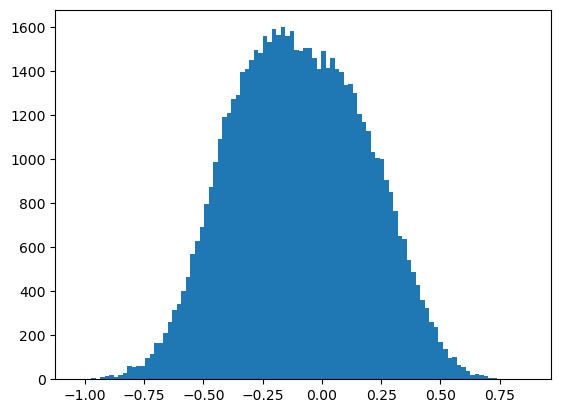

In [6]:
plt.hist(raw1_label[4, 0].numpy().flatten(), bins=100)
plt.show()

In [7]:
#import torch
#torch.unique(raw1_label[:, 1:2, ...])

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(np.squeeze(raw[0].numpy()), cmap="gray")
axs[0].set_title("raw")
axs[1].imshow(np.squeeze(label[0].numpy()), cmap="gray")
axs[1].set_title("label")
plt.show()

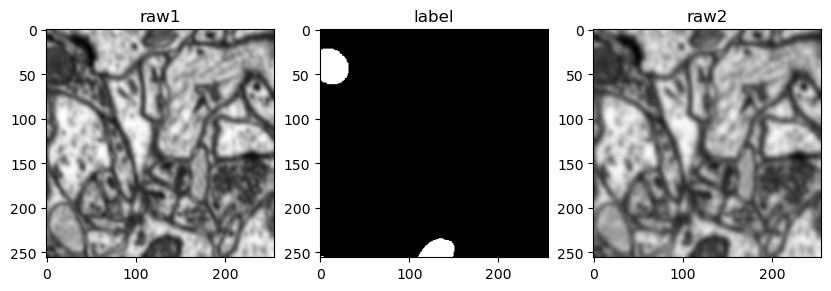

In [7]:
_, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(np.squeeze(raw1_label[0, 0].numpy()), cmap="gray")
axs[0].set_title("raw1")
axs[1].imshow(np.squeeze(raw1_label[0, 1].numpy()), cmap="gray")
axs[1].set_title("label")
axs[2].imshow(np.squeeze(raw2[0].numpy()), cmap="gray")
axs[2].set_title("raw2")
plt.show()


In [7]:
model_cfg: Dict[str, Any] = {
    "name": "UNet2d_as3d",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "feature_return": False,
    "is_segmentation": True,
    "feature_perturbation": None
}
model = get_model(model_cfg)
source_checkpoint = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Hmito/BatchNorm/Hm_model3/best_checkpoint.pytorch"
load_checkpoint(source_checkpoint, model)
model.eval()

/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location="cpu")


UNet2d_as3d(
  (encoders): ModuleList(
    (0): Encoder(
      (basic_module): DoubleConv(
        (SingleConv1): SingleConv(
          (batchnorm): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (ReLU): ReLU(inplace=True)
        )
        (SingleConv2): SingleConv(
          (batchnorm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (ReLU): ReLU(inplace=True)
        )
      )
    )
    (1): Encoder(
      (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (basic_module): DoubleConv(
        (SingleConv1): SingleConv(
          (batchnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv): Conv2d(32, 32, kernel_size=(3, 3), 

In [ ]:
import torch
from tqdm import tqdm

f1_per_batch = []
with torch.no_grad():
    for raw, label in tqdm(loader):
        pred = model(raw)
        # _, axs = plt.subplots(1, 3, figsize=(10, 5))
        # axs[0].imshow(np.squeeze(raw[0].numpy()), cmap="gray")
        # axs[0].set_title("raw")
        # axs[1].imshow(np.squeeze(label[0].numpy()), cmap="gray")
        # axs[1].set_title("label")
        # axs[2].imshow(np.squeeze(pred[0].numpy()), cmap="gray")
        # axs[2].set_title("pred")
        # plt.show()
        #print(pred.min(), pred.max())
        f1_scores = MultiClassF1Eval()(pred, label)
        f1_per_batch.append(f1_scores.detach().cpu().numpy())

100%|██████████| 20/20 [02:37<00:00,  7.85s/it]


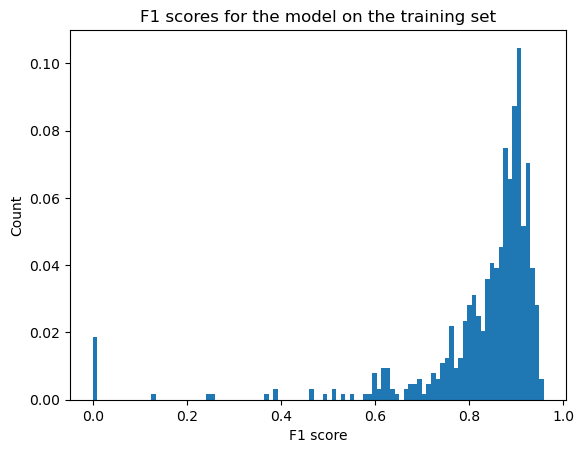

In [ ]:
_ = plt.hist(np.concatenate(f1_per_batch)[:,1], bins=100, weights=np.ones(len(np.concatenate(f1_per_batch))) / len(np.concatenate(f1_per_batch)))
_ = plt.xlabel("F1 score")
_ = plt.ylabel("Count")
_ = plt.title("F1 scores for the model on the training set")
plt.show()

In [9]:
import torch
from tqdm import tqdm

f1_per_batch = []
with torch.no_grad():
    for raw1_label, raw2 in tqdm(loader):
        pred = model(raw1_label[:, 0:1, ...])
        # _, axs = plt.subplots(1, 3, figsize=(10, 5))
        # axs[0].imshow(np.squeeze(raw1_label[0, 0].numpy()), cmap="gray")
        # axs[0].set_title("raw1")
        # axs[1].imshow(np.squeeze(raw1_label[0, 1].numpy()), cmap="gray")
        # axs[1].set_title("label")
        # axs[2].imshow(np.squeeze(pred[0].numpy()), cmap="gray")
        # axs[2].set_title("pred")
        # plt.show()
        #print(pred.min(), pred.max())
        f1_scores = MultiClassF1Eval()(pred, raw1_label[:, 1:2, ...])
        f1_per_batch.append(f1_scores.detach().cpu().numpy())
        #break
        
    

100%|██████████| 20/20 [02:41<00:00,  8.10s/it]


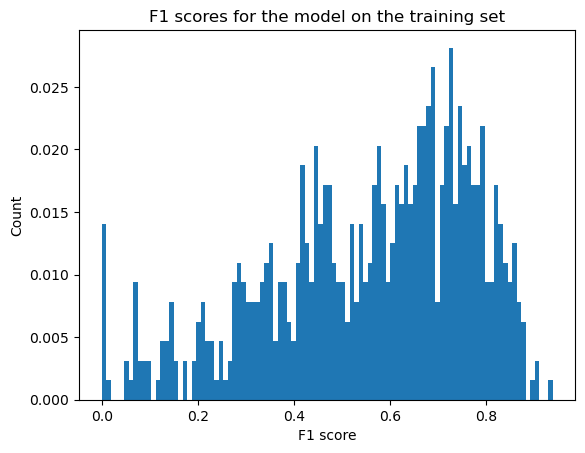

In [10]:
_ = plt.hist(np.concatenate(f1_per_batch)[:,1], bins=100, weights=np.ones(len(np.concatenate(f1_per_batch))) / len(np.concatenate(f1_per_batch)))
_ = plt.xlabel("F1 score")
_ = plt.ylabel("Count")
_ = plt.title("F1 scores for the model on the training set")
plt.show()

In [ ]:
from model_ranking.datasets import get_loaders
from model_ranking import (
    EPFLTargetConfig,
)

target_config = EPFLTargetConfig()

with torch.no_grad():
    for loader in get_loaders(
        target_config,
        phase="train",
        output_path=None,
        shuffle=False,
    ):
        raw, label = next(iter(loader))

In [8]:
loader2 = get_DummySelfTraining_loader(
    paths=data_cfg["unsupervised_train_paths"],
    raw_key=data_cfg["raw_key"],
    label_key=data_cfg["label_key"],
    patch_shape=data_cfg["patch_shape"],
    batch_size=data_cfg["batch_size"],
    num_workers=data_cfg["num_workers"],
    n_samples=data_cfg["n_samples_train"],
    global_stats=None,
    norm01=False,
)

100%|██████████| 20/20 [02:47<00:00,  8.36s/it]


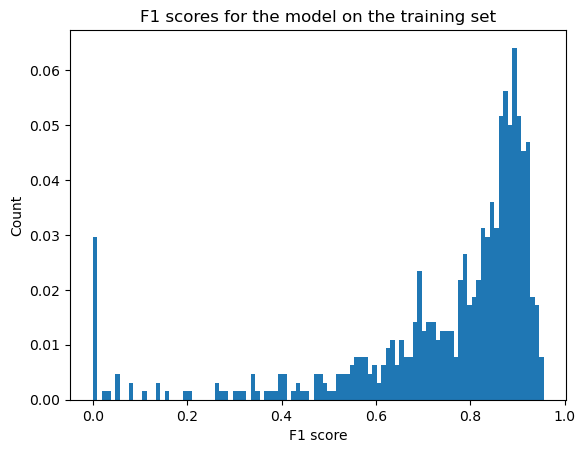

In [9]:
import torch
from tqdm import tqdm

f1_per_batch = []
with torch.no_grad():
    for raw1_label, raw2 in tqdm(loader2):
        pred = model(raw1_label[:, 0:1, ...])
        # _, axs = plt.subplots(1, 3, figsize=(10, 5))
        # axs[0].imshow(np.squeeze(raw1_label[0, 0].numpy()), cmap="gray")
        # axs[0].set_title("raw1")
        # axs[1].imshow(np.squeeze(raw1_label[0, 1].numpy()), cmap="gray")
        # axs[1].set_title("label")
        # axs[2].imshow(np.squeeze(pred[0].numpy()), cmap="gray")
        # axs[2].set_title("pred")
        # plt.show()
        #print(pred.min(), pred.max())
        f1_scores = MultiClassF1Eval()(pred, raw1_label[:, 1:2, ...])
        f1_per_batch.append(f1_scores.detach().cpu().numpy())
_ = plt.hist(np.concatenate(f1_per_batch)[:,1], bins=100, weights=np.ones(len(np.concatenate(f1_per_batch))) / len(np.concatenate(f1_per_batch)))
_ = plt.xlabel("F1 score")
_ = plt.ylabel("Count")
_ = plt.title("F1 scores for the model on the training set")
plt.show()

In [ ]:
from model_ranking.datasets import get_loaders
from model_ranking import (
    EPFLTargetConfig,
)

target_config = EPFLTargetConfig()

with torch.no_grad():
    for loader in get_loaders(
        target_config,
        phase="train",
        output_path=None,
        shuffle=False,
    ):
        f1_per_batch = []
        # Iterate over batches in the loader, run model prediction, compute F1 scores, and append to f1_per_batch
        for i, (raw, label) in enumerate(tqdm(loader)):
            pred = model(raw)
            print(pred.min(), pred.max())
            f1_scores = MultiClassF1Eval()(pred, label)
            f1_per_batch.append(f1_scores.detach().cpu().numpy())

2025-07-09 19:11:58,788 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/train.h5...
2025-07-09 19:11:58,789 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5509082674980164, global std: 0.11770268529653549
2025-07-09 19:11:59,345 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-07-09 19:11:59,356 [MainThread] INFO HDF5Dataset - Number of patches: 990


  1%|          | 1/99 [00:03<05:09,  3.16s/it]

tensor(3.2636e-05) tensor(1.)


  2%|▏         | 2/99 [00:05<04:18,  2.66s/it]

tensor(3.6378e-05) tensor(1.)


...

tensor(4.0871e-05) tensor(1.)


 99%|█████████▉| 98/99 [03:46<00:02,  2.25s/it]

tensor(2.9825e-05) tensor(1.)


100%|██████████| 99/99 [03:48<00:00,  2.31s/it]

tensor(2.9079e-05) tensor(1.)


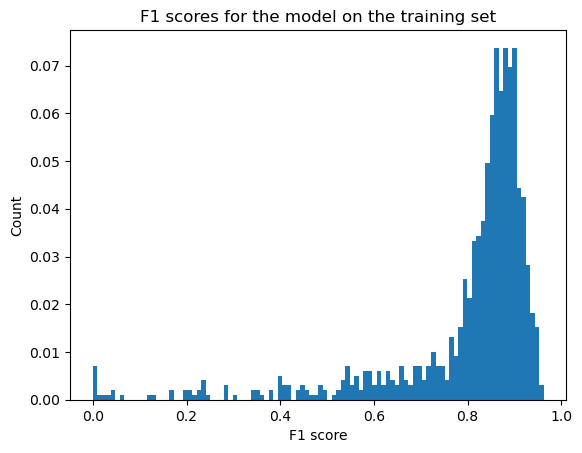

In [13]:
_ = plt.hist(np.concatenate(f1_per_batch)[:,1], bins=100, weights=np.ones(len(np.concatenate(f1_per_batch))) / len(np.concatenate(f1_per_batch)))
_ = plt.xlabel("F1 score")
_ = plt.ylabel("Count")
_ = plt.title("F1 scores for the model on the training set")
plt.show()